# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [4]:
import math
import sys

In [5]:
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install numpy

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

In [7]:
import yaml

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

# IRIS

In [8]:
iris = pd.read_csv('iris.tsv.gz', sep='\t', compression='gzip')
summary = pd.read_csv('summary_stats.tsv', sep='\t')  
   

In [9]:
import os
print(os.getcwd())

/workspaces/dx601-project-Manning


In [10]:
print(os.listdir())

['bezdekIris.data', 'final_project.ipynb', 'Index', 'iris.data', 'summary_stats.tsv', 'config.yaml', 'iris.names', 'metadata.yaml', '.git', 'iris.tsv.gz']


In [11]:
with open("config.yaml", "r") as f:
    meta = yaml.safe_load(f)

meta    

{'metadata_file': 'metadata.yaml',
 'data_file': 'summary_stats.tsv',
 'separator': '\t'}

In [12]:
iris

,sepal-length,sepal-width,petal-length,petal-width,target
0,6.7,3.0,5.2,2.3,2
1,6.0,2.2,5.0,1.5,2
2,6.2,2.8,4.8,1.8,2
3,7.7,3.8,6.7,2.2,2
4,7.2,3.0,5.8,1.6,2
...,...,...,...,...,...
145,5.0,3.5,1.6,0.6,0
146,5.4,3.9,1.7,0.4,0
147,5.1,3.4,1.5,0.2,0
148,5.0,3.6,1.4,0.2,0


YOUR ANSWERS HERE

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

# Column Descriptions:

_Sepal_ - lower leaf like features of the iris that protect the buds from being damaged from insects or heat. They often create a landing pad for bumble bees. The sepals remain on the flower unlike the petals   
_sepal-length_ -measurement from base to tip   
_sepal-width_ -measurement from furthest points perpendicular to length   
_Petal_ - colored upright structure to the iris, often referred to as standards  
_petal-length_ -measurement from base to tip   
_petal-width_ -measurement from furthest points perpendicular to length  
_target_ - classification of each iris per row  
"The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.  One class is linearly separable from the other 2; the latter are not linearly separable from each other."  
 Iris Setosa, Iris Versicolour, or Iris Virginica

In [13]:
iris.describe()

,sepal-length,sepal-width,petal-length,petal-width,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

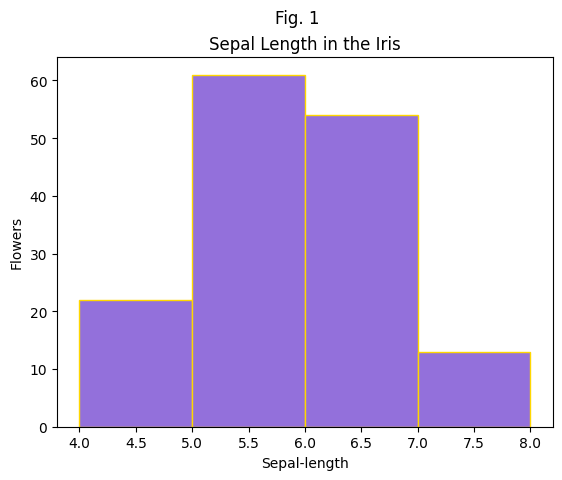

In [14]:
plt.hist(iris['sepal-length'], bins=range(int(iris['sepal-length'].min()), int(iris['sepal-length'].max())+2), color= 'mediumpurple',  edgecolor='gold')
plt.title('Sepal Length in the Iris')
plt.suptitle('Fig. 1')
plt.xlabel('Sepal-length')
plt.ylabel('Flowers')
plt.show()

In [15]:
iris['sepal-width'].skew()

np.float64(0.3340526621720865)

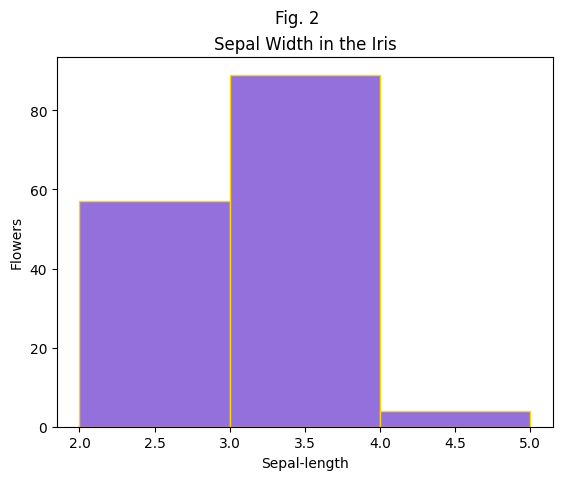

In [16]:
plt.hist(iris['sepal-width'], bins=range(int(iris['sepal-width'].min()), int(iris['sepal-width'].max())+2), color= 'mediumpurple',  edgecolor='gold')
plt.title('Sepal Width in the Iris')
plt.suptitle('Fig. 2')
plt.xlabel('Sepal-length')
plt.ylabel('Flowers')
plt.show()

In [17]:
iris['sepal-length'].skew()

np.float64(0.3149109566369726)

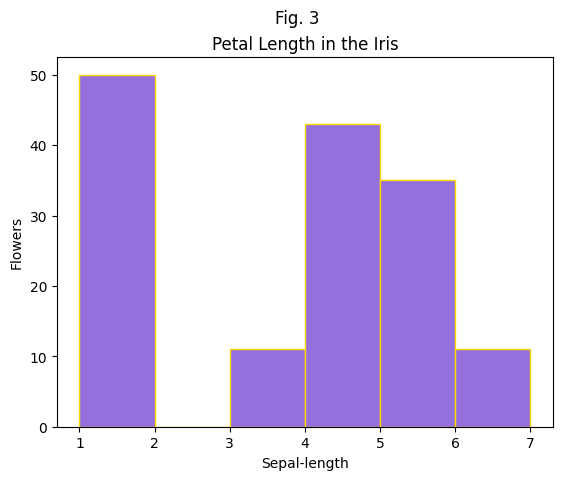

In [18]:
plt.hist(iris['petal-length'], bins=range(int(iris['petal-length'].min()), int(iris['petal-length'].max())+2), color= 'mediumpurple',  edgecolor='gold')
plt.title('Petal Length in the Iris')
plt.suptitle('Fig. 3')
plt.xlabel('Sepal-length')
plt.ylabel('Flowers')
plt.show()

In [19]:
iris['petal-length'].skew()

np.float64(-0.2744642524737843)

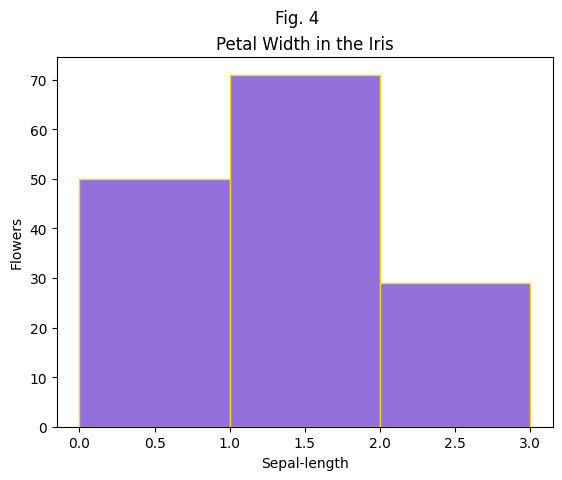

In [20]:
plt.hist(iris['petal-width'], bins=range(int(iris['petal-width'].min()), int(iris['petal-width'].max())+2), color= 'mediumpurple',  edgecolor='gold')
plt.title('Petal Width in the Iris')
plt.suptitle('Fig. 4')
plt.xlabel('Sepal-length')
plt.ylabel('Flowers')
plt.show()

In [21]:
iris['petal-width'].skew()

np.float64(-0.10499656214412734)

YOUR ANSWERS HERE

# Distributions:  
Sepal Length - normal distribution  
Sepal Width - approximately normal, slightly right skewed  
Petal Length - left skewed  
Petal Width - approximately normal, slightly left skewed  

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

<Figure size 800x500 with 0 Axes>

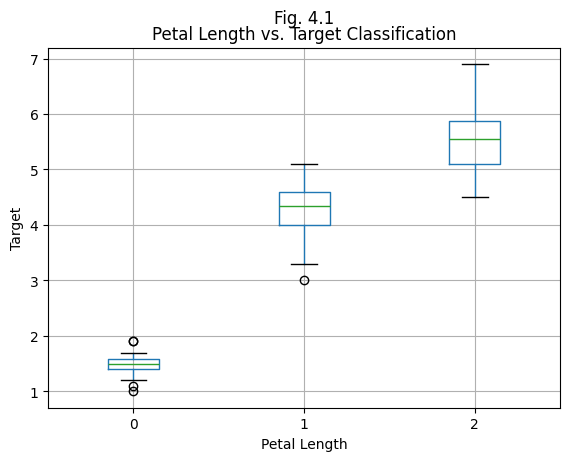

In [22]:
plt.figure(figsize=(8, 5))
iris.boxplot(column='petal-length', by='target')
plt.title("Petal Length vs. Target Classification")
plt.suptitle('Fig. 4.1') 
plt.xlabel('Petal Length')
plt.ylabel('Target')
plt.show()

<Figure size 800x500 with 0 Axes>

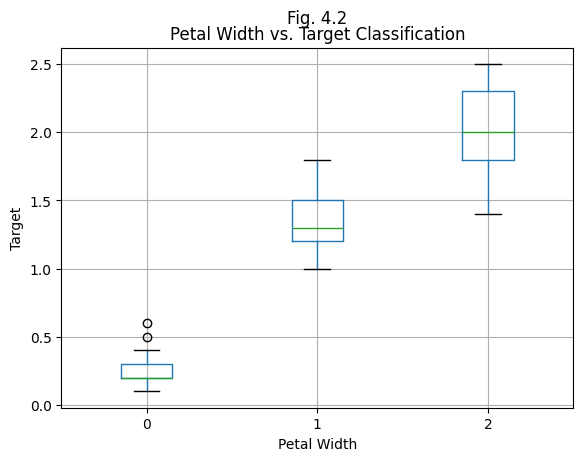

In [23]:
plt.figure(figsize=(8, 5))
iris.boxplot(column='petal-width', by='target')
plt.title("Petal Width vs. Target Classification")
plt.suptitle('Fig. 4.2') 
plt.xlabel('Petal Width')
plt.ylabel('Target')
plt.show()

<Figure size 800x500 with 0 Axes>

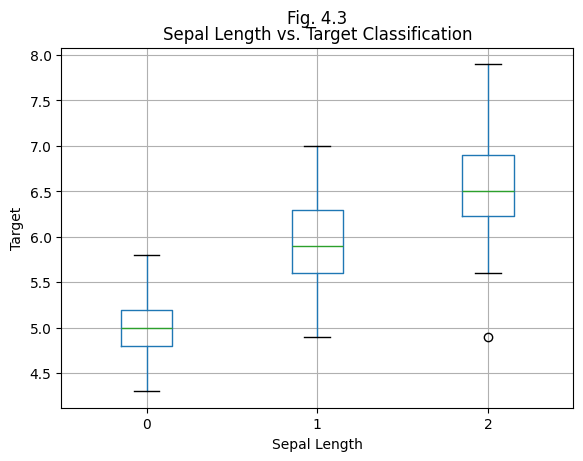

In [24]:
plt.figure(figsize=(8, 5))
iris.boxplot(column='sepal-length', by='target')
plt.title("Sepal Length vs. Target Classification")
plt.suptitle('Fig. 4.3') 
plt.xlabel('Sepal Length')
plt.ylabel('Target')
plt.show()

<Figure size 800x500 with 0 Axes>

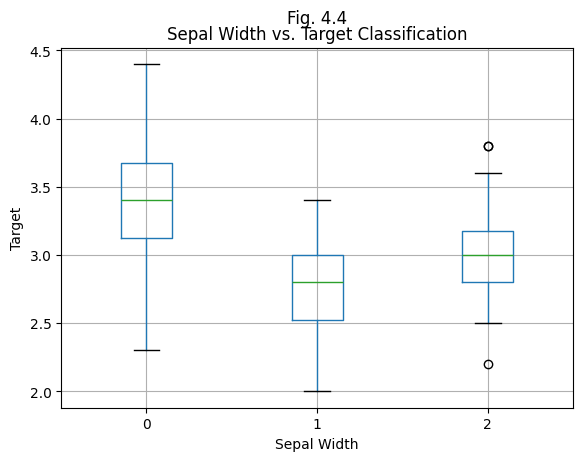

In [25]:
plt.figure(figsize=(8, 5))
iris.boxplot(column='sepal-width', by='target')
plt.title("Sepal Width vs. Target Classification")
plt.suptitle('Fig. 4.4') 
plt.xlabel('Sepal Width')
plt.ylabel('Target')
plt.show()

YOUR ANSWERS HERE

# Variable Independence:  

petal length - not independent - large difference between medians, length increase refers to different class, easy to predict.     
petal width - not independent - large difference between medians, width increase refers to different class, easy to predict.      
sepal length - not independent - large difference between medians, length increase refers to different class, easy to predict.    
sepal width - independent - the box plots are very close to each other so differences are small, harder to predict.   

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [27]:

X = iris.drop(columns= 'target') # features
y = iris['target'] # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear = LinearRegression()
linear.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
linear_y_pred = linear.predict(X_test) #predictions

In [29]:
mse = mean_squared_error(y_test, linear_y_pred)
print("MSE:", mse)

MSE: 0.038500811423322574


In [30]:
full_pred = linear.predict(X)

In [31]:
full_mse = mean_squared_error(y, full_pred)
print("Full Dataset MSE:", full_mse)

Full Dataset MSE: 0.046385088311226945


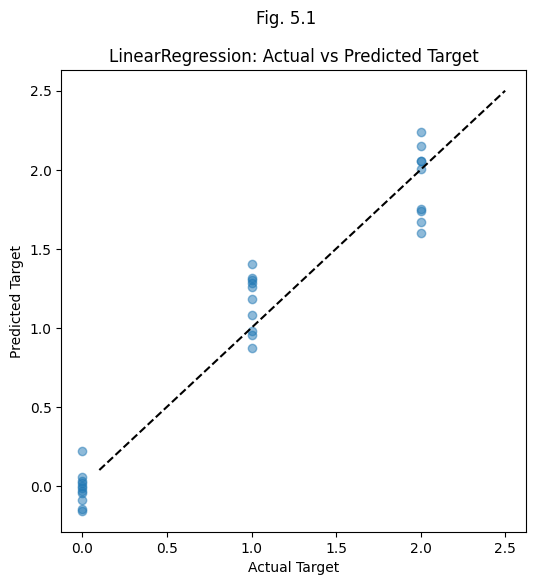

In [60]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, linear_y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')#lw=2) 
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('LinearRegression: Actual vs Predicted Target')
plt.suptitle('Fig. 5.1') 
plt.show()

YOUR ANSWERS HERE

MSE on Full Dataset: 0.046385088311226945  

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


YOUR ANSWERS HERE

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width']

for col in features:
    X = iris[[col]]
    y = iris['target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    score = model.score(X_test, y_test)  # R^2
    print(f"{col}: {score:.3f}")

sepal-length: 0.543
sepal-width: 0.243
petal-length: 0.911
petal-width: 0.920


In [34]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
linearpred = model.predict(X_test)

In [36]:
mse6 = mean_squared_error(y_test, linearpred)
print("MSE:", mse)

MSE: 0.038500811423322574


Petal length and width are the best predictors for classification of iris plant.  Sepal width is the worst predictor.  The single feature model in problem 6 is a better model with a lower MSE but for this particular dataset the petal width is such a large indicator for target classification that it almost doesn't matter.

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

YOUR ANSWERS HERE

In [37]:
#split
x = iris['petal-length']
y = iris['petal-width']

t = x.median()
print(t)

left = iris[iris['petal-length'] < t]
right = iris[iris['petal-length'] >= t]

4.35


petal length and petal width are my strongest dependent variables. 

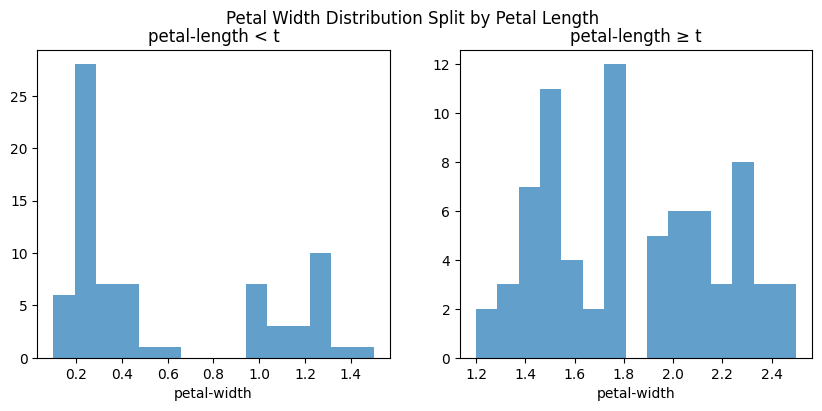

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(left['petal-width'], bins=15, alpha=0.7)
plt.title("petal-length < t")
plt.xlabel("petal-width")

plt.subplot(1,2,2)
plt.hist(right['petal-width'], bins=15, alpha=0.7)
plt.title("petal-length ≥ t")
plt.xlabel("petal-width")

plt.suptitle("Petal Width Distribution Split by Petal Length")
plt.show()

Petal length and width are strongly dependent of each other. When petal length is small so it petal width and when petal length is large, so is petal width. This also supports the earlier findings that both variables haves strong predictive relationships between the target classification for the flower

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

In [39]:
from sklearn.decomposition import PCA

In [40]:
iris_pca_columns = [c for c in iris.columns if iris[c].dtype =='float64']
iris_pca_columns

['sepal-length', 'sepal-width', 'petal-length', 'petal-width']

In [41]:
iris_pca = PCA()
iris_pca.fit(iris[iris_pca_columns].dropna())
iris_components = pd.DataFrame(iris_pca.components_, columns=iris_pca_columns)
iris_components

,sepal-length,sepal-width,petal-length,petal-width
0,0.361590,-0.082269,0.856572,0.358844
1,0.656540,0.729712,-0.175767,-0.074706
2,-0.580997,0.596418,0.072524,0.549061
3,0.317255,-0.324094,-0.479719,0.751121


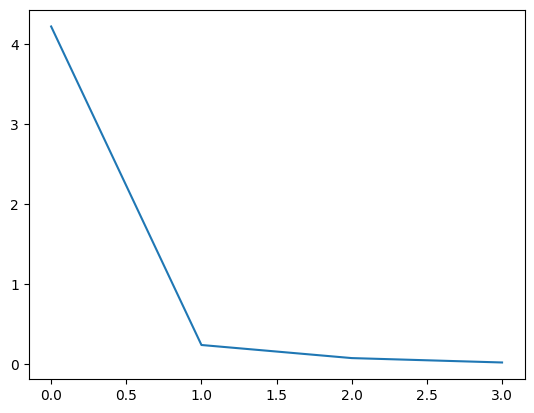

In [42]:
plt.plot(iris_pca.explained_variance_)
None

In [43]:
iris[iris_pca_columns].head()

,sepal-length,sepal-width,petal-length,petal-width
0,6.7,3.0,5.2,2.3
1,6.0,2.2,5.0,1.5
2,6.2,2.8,4.8,1.8
3,7.7,3.8,6.7,2.2
4,7.2,3.0,5.8,1.6


In [44]:
iris_components

,sepal-length,sepal-width,petal-length,petal-width
0,0.361590,-0.082269,0.856572,0.358844
1,0.656540,0.729712,-0.175767,-0.074706
2,-0.580997,0.596418,0.072524,0.549061
3,0.317255,-0.324094,-0.479719,0.751121


In [45]:
(iris[iris_pca_columns] @ iris_components.T).var(axis=0)

0    4.224841
1    0.242244
2    0.078524
3    0.023683
dtype: float64

In [46]:
iris_pca.explained_variance_

array([4.22484077, 0.24224357, 0.07852391, 0.02368303])

YOUR ANSWERS HERE

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [47]:
# YOUR CODE HERE

YOUR ANSWERS HERE

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

sepal width classification 2, creates a harder predictive quality for the dataset and target.  

In [48]:
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

In [ ]:

X = iris.drop(columns=['target'], errors='ignore')

z_scores = X.apply(zscore)

for col in X.columns:
    iris[f'z_{col}'] = z_scores[col]

z_outliers = iris[(z_scores.abs() > 3).any(axis=1)]
z_outliers

,sepal-length,sepal-width,petal-length,petal-width,target,outlier,z_sepal-length,z_sepal-width,z_petal-length,z_petal-width,z_outlier,z_z_sepal-length,z_z_sepal-width,z_z_petal-length,z_z_petal-width,z_z_outlier,z_z_z_sepal-length,z_z_z_sepal-width,z_z_z_petal-length,z_z_z_petal-width,z_z_z_outlier,z_z_z_z_sepal-length,z_z_z_z_sepal-width,z_z_z_z_petal-length,z_z_z_z_petal-width,z_z_z_z_outlier
3,7.7,3.8,6.7,2.2,2,-1,2.249683,1.726266,1.672610,1.316483,-4.213075,2.249683,1.726266,1.672610,1.316483,-4.213075,2.249683,1.726266,1.672610,1.316483,-4.213075,2.249683,1.726266,1.672610,1.316483,-4.213075
33,7.9,3.8,6.4,2.0,2,-1,2.492019,1.726266,1.502013,1.053537,-4.213075,2.492019,1.726266,1.502013,1.053537,-4.213075,2.492019,1.726266,1.502013,1.053537,-4.213075,2.492019,1.726266,1.502013,1.053537,-4.213075
49,4.9,2.5,4.5,1.7,2,-1,-1.143017,-1.281972,0.421564,0.659118,-4.213075,-1.143017,-1.281972,0.421564,0.659118,-4.213075,-1.143017,-1.281972,0.421564,0.659118,-4.213075,-1.143017,-1.281972,0.421564,0.659118,-4.213075
57,4.5,2.3,1.3,0.3,0,-1,-1.627688,-1.744778,-1.398138,-1.181504,-4.213075,-1.627688,-1.744778,-1.398138,-1.181504,-4.213075,-1.627688,-1.744778,-1.398138,-1.181504,-4.213075,-1.627688,-1.744778,-1.398138,-1.181504,-4.213075
94,7.7,2.6,6.9,2.3,2,-1,2.249683,-1.050569,1.786341,1.447956,-4.213075,2.249683,-1.050569,1.786341,1.447956,-4.213075,2.249683,-1.050569,1.786341,1.447956,-4.213075,2.249683,-1.050569,1.786341,1.447956,-4.213075
116,5.8,4.0,1.2,0.2,0,-1,-0.052506,2.189072,-1.455004,-1.312977,-4.213075,-0.052506,2.189072,-1.455004,-1.312977,-4.213075,-0.052506,2.189072,-1.455004,-1.312977,-4.213075,-0.052506,2.189072,-1.455004,-1.312977,-4.213075
118,5.7,4.4,1.5,0.4,0,-1,-0.173674,3.114684,-1.284407,-1.050031,-4.213075,-0.173674,3.114684,-1.284407,-1.050031,-4.213075,-0.173674,3.114684,-1.284407,-1.050031,-4.213075,-0.173674,3.114684,-1.284407,-1.050031,-4.213075
130,4.3,3.0,1.1,0.1,0,-1,-1.870024,-0.124958,-1.511870,-1.444450,-4.213075,-1.870024,-0.124958,-1.511870,-1.444450,-4.213075,-1.870024,-0.124958,-1.511870,-1.444450,-4.213075,-1.870024,-0.124958,-1.511870,-1.444450,-4.213075


In [51]:
iso = IsolationForest(contamination=0.05)
iris['outlier'] = iso.fit_predict(iris)

outliers = iris[iris['outlier'] == -1]
outliers

,sepal-length,sepal-width,petal-length,petal-width,target,outlier
3,7.7,3.8,6.7,2.2,2,-1
33,7.9,3.8,6.4,2.0,2,-1
49,4.9,2.5,4.5,1.7,2,-1
57,4.5,2.3,1.3,0.3,0,-1
94,7.7,2.6,6.9,2.3,2,-1
116,5.8,4.0,1.2,0.2,0,-1
118,5.7,4.4,1.5,0.4,0,-1
130,4.3,3.0,1.1,0.1,0,-1


I was going to check z score but AI mentioned that zscore is better for one variable while the isolation forest is best with multiple features

In [55]:
outlier_row = outliers.iloc[0]


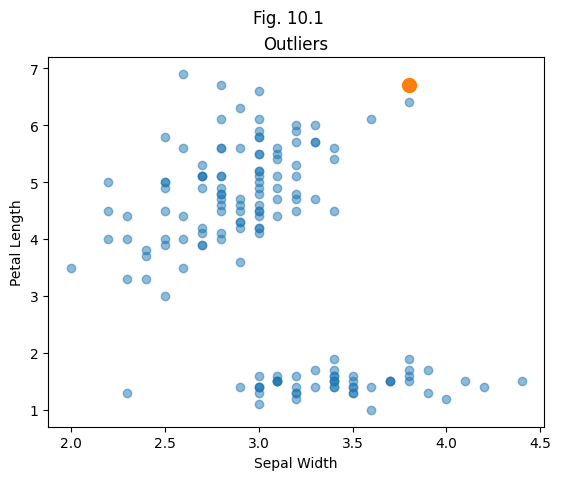

In [61]:
plt.scatter(iris['sepal-width'], iris['petal-length'], alpha=0.5)

# Highlight outlier
plt.scatter(outlier_row['sepal-width'],
            outlier_row['petal-length'],
            s=100)

plt.xlabel('Sepal Width')
plt.ylabel('Petal Length')
plt.title('Outliers')
plt.suptitle('Fig. 10.1') 

plt.show()

YOUR ANSWERS HERE

The sepal width was the most independent of all variables. Potential outliers were found by examining the relationship between sepal width and other variables. The outlier is sitting a little off from the rest of the data in the graph (fig 10.1). When sepal width is compared to petal width the outliers is not as much apparant as the petal length but still shows a weak relation as shown in the graph below (fig 10.2) 

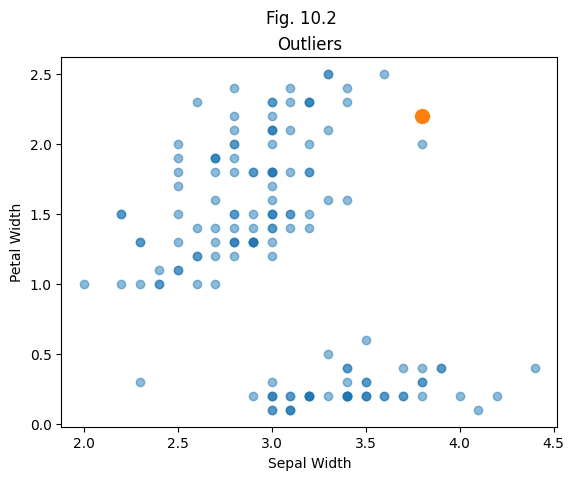

In [62]:
plt.scatter(iris['sepal-width'], iris['petal-width'], alpha=0.5)

# Highlight outlier
plt.scatter(outlier_row['sepal-width'],
            outlier_row['petal-width'],
            s=100)

plt.xlabel('Sepal Width')
plt.ylabel('Petal Width')
plt.title('Outliers')
plt.suptitle('Fig. 10.2') 

plt.show()

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

AI assisted in writing some of the code but I was able to use a lot of my wine set project from DX602 to help with graphing. As well as outlier finding, rather than zscore I switched to isolation forest